# Random points generation for product validation (paddy fidels clusters) by year

## Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon
from shapely.geometry import shape
from shapely.geometry import Point
import random

## Data importing and processing

In [5]:
# Import data from GH repo
!wget https://raw.githubusercontent.com/francobarrionuevoenv21/ClusteringPaddyFields_Fires_SanJavier/refs/heads/main/Primary_data/Planicie_con_paleocauces_NW-SW_4326.geojson
!wget https://raw.githubusercontent.com/francobarrionuevoenv21/ClusteringPaddyFields_Fires_SanJavier/refs/heads/main/Data_results/05_ArrocerasBBSS_discriminadasIni%26Fin_Junio2024v03.geojson

--2025-08-18 00:35:02--  https://raw.githubusercontent.com/francobarrionuevoenv21/ClusteringPaddyFields_Fires_SanJavier/refs/heads/main/Primary_data/Planicie_con_paleocauces_NW-SW_4326.geojson
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 162765 (159K) [text/plain]
Saving to: ‘Planicie_con_paleocauces_NW-SW_4326.geojson.2’

Planicie_con_paleoc 100%[===================>] 158.95K  --.-KB/s    in 0.02s   

2025-08-18 00:35:02 (6.83 MB/s) - ‘Planicie_con_paleocauces_NW-SW_4326.geojson.2’ saved [162765/162765]

--2025-08-18 00:35:02--  https://raw.githubusercontent.com/francobarrionuevoenv21/ClusteringPaddyFields_Fires_SanJavier/refs/heads/main/Data_results/05_ArrocerasBBSS_discriminadasIni%26Fin_Junio2024v03.geojson
Resolving raw.githubusercontent.com (raw.git

In [6]:
# Load vectors data

targetCRS = "EPSG:4326"

vectorArrocDisc = gpd.read_file('/content/05_ArrocerasBBSS_discriminadasIni&Fin_Junio2024v03.geojson').to_crs(targetCRS)
vectorPdePC = gpd.read_file('/content/Planicie_con_paleocauces_NW-SW_4326.geojson').to_crs(targetCRS)

In [15]:
# Display paddy fields vector data
vectorArrocDisc.head()

,ID_arroc,anio_ini,anio_fin,geometry
0,16,2004,2022,"MULTIPOLYGON (((-59.97516 -30.41397, -59.97499..."
1,8,2009,2022,"MULTIPOLYGON (((-60.16691 -30.7328, -60.16682 ..."
2,3,2005,2018,"MULTIPOLYGON (((-60.07641 -30.34001, -60.07638..."
3,8,2009,2022,"MULTIPOLYGON (((-60.15344 -30.70537, -60.15354..."
4,12,2012,2021,"MULTIPOLYGON (((-60.07945 -30.42096, -60.07945..."


## Random points generation

#### Satellite images downloaded for validation

* L7 - '2008-11-01', '2009-02-28' --> Filter paddy fields vector by >= 2008
* L8 01 - '2014-11-01', '2015-02-28' --> Filter paddy fields vector by >= 2014
* L8 02 - '2020-11-01', '2021-02-28' --> Filter paddy fields vector by >= 2020

In [11]:
# Select year for paddy fields vector filtering
year = 2020

In [17]:
# Paddy fields vector filtering by year
vectorAAxAnio = vectorArrocDisc.copy()
if year != 2022:
  vectorAAxAnio_undiss = vectorAAxAnio[(vectorAAxAnio['anio_ini'] <= year) & (vectorAAxAnio['anio_fin'] > year)]
else:
  vectorAAxAnio_undiss = vectorAAxAnio[(vectorAAxAnio['anio_fin'] == year)]
vectorAAxAnio_diss = vectorAAxAnio_undiss.dissolve() # Obtained vector dissolved

In [19]:
# Obtain the difference between the paddy fields vector and the planicie vector
# Points within this vector are labeled as non-paddy field
vectorPdePC_diff = vectorPdePC.difference(vectorAAxAnio_diss)

In [20]:
# Function to generate random points within vectors
point_index = 1

def gen_randomPoints(gdf, classf, num_points):
  global point_index
  # Create an empty GeoDataFrame to store random points
  random_points_gdf = gpd.GeoDataFrame()

  random_points = []
  cluster = []
  clasf_byVector = []

  polygon = gdf
  minx, miny, maxx, maxy = polygon.bounds
  if not polygon.is_valid:
    polygon = polygon.buffer(0) #  .buffer(0) method resolves minor topological issues.

  # Generate random points within the polygon boundary
  while len(random_points) < num_points: #for _ in range(num_points):
      # Generate random coordinates within the bounding box of the polygon
      x = np.random.uniform(minx, maxx)
      y = np.random.uniform(miny, maxy)
      #print(x, y)

      # Create a point geometry
      point = Point(x, y)

      # Check if the point is within the polygon
      if point.within(polygon):
          random_points.append(point)
          cluster.append(f'{str(point_index)}')
          clasf_byVector.append(classf)
          point_index += 1

  data = {'cluster': cluster, 'geometry': random_points, 'clasf_byVector': clasf_byVector}
  gdf_points = gpd.GeoDataFrame(data, crs=targetCRS)

  return gdf_points

In [21]:
# Points generation by type

'''
Generation of random points. The methodology includes generating in total 100 points, 70 corresponding to non-paddy fields (n_random=0)
and 30 corresponding to paddy fields (n_random=1). Which are generated, first is also defined randomly
'''

n_random = random.randint(0, 1)

for i in range(2):
  if n_random == 0:
    points_noArroc = gen_randomPoints(vectorPdePC_diff.to_crs(targetCRS)[0], 0, 70) # 0: non-paddy field; 1: paddy field
    n_random = 1
  else:
    points_Arroc = gen_randomPoints(vectorAAxAnio_diss['geometry'].to_crs(targetCRS)[0], 1, 30) # 0: non-paddy field; 1: paddy field
    n_random = 0

/tmp/ipython-input-921590097.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs.legend(fontsize=12)
/tmp/ipython-input-921590097.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels(axs.get_xticklabels(), rotation=45, ha='right', fontsize=11)


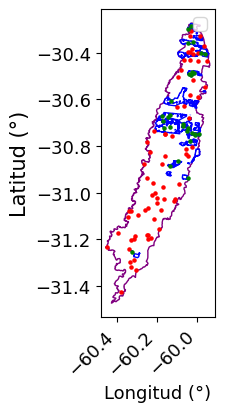

In [31]:
# @title ##### Display generated data (optional)

# Display generated data
fig, axs = plt.subplots(figsize=(4, 4))

vectorPdePC.to_crs(targetCRS).plot(ax=axs, color='none', edgecolor='purple')
vectorAAxAnio_diss.to_crs(targetCRS).plot(ax=axs, color='none', edgecolor='blue')
points_noArroc.plot(ax=axs, color='red', markersize=5)
points_Arroc.plot(ax=axs, color='green', markersize=5)

axs.set_ylabel('Latitud (°)', fontsize=15)
axs.set_xlabel('Longitud (°)', fontsize=13)
axs.legend(fontsize=12)

# Adjust the frequency of x-axis ticks
axs.xaxis.set_major_locator(plt.MultipleLocator(base=0.2))  # Adjust to desired frequency
axs.set_xticklabels(axs.get_xticklabels(), rotation=45, ha='right', fontsize=11)
axs.tick_params(axis='both', labelsize=13)

plt.show()

In [33]:
# Create a dataframe with generated random points to define ground truth values (clasf_groundTruth)

gdf_concat = pd.concat([points_noArroc, points_Arroc])
gdf_concat['clasf_groundTruth'] = pd.Series(dtype='int')
gdf_concat = gdf_concat.sample(frac = 1) # Shufflering of data by rows

In [34]:
# Display dataframe with points
gdf_concat.head()

,cluster,geometry,clasf_byVector,clasf_groundTruth
67,68,POINT (-59.99635 -30.43318),0,NaN
7,78,POINT (-60.03379 -30.49496),1,NaN
34,35,POINT (-60.03701 -30.58024),0,NaN
22,23,POINT (-60.33529 -31.29741),0,NaN
16,87,POINT (-60.16888 -30.72055),1,NaN


## Data exporting

In [ ]:
# Vector with points exporting to define ground truth values
gdf_concat.drop(columns=['clasf_byVector']).to_file(f'random_points_{year}_toGT.geojson')

# Points classified data exporting for metrics computing
gdf_concat.drop(columns=['geometry', 'clasf_groundTruth']).to_csv(f'random_points_{year}_clasf.csv', index=False)